In [1]:
!pip install -q transformers torch pandas numpy tqdm

the number of corpus chunks: 341 | testing queries: 30


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Calculating scores: 100%|██████████| 30/30 [00:10<00:00,  2.85it/s]


Search Combination (BGE-M3)  Acc@1 (%)  Acc@3 (%)  Acc@5 (%)  P@3 (%)  P@5 (%)  F1@3 (%)  F1@5 (%)   MRR  NDCG@3   MAP
                 Dense Only      60.00      86.67      90.00    28.89    18.00     43.33     30.00 0.729   0.772 0.729
                Sparse Only      26.67      40.00      56.67    13.33    11.33     20.00     18.89 0.349   0.402 0.349
               ColBERT Only      70.00      80.00      83.33    26.67    16.67     40.00     27.78 0.758   0.777 0.758
    Hybrid (Sparse + Dense)      36.67      63.33      70.00    21.11    14.00     31.67     23.33 0.500   0.551 0.500
  Hybrid (Sparse + ColBERT)      53.33      73.33      73.33    24.44    14.67     36.67     24.44 0.622   0.651 0.622


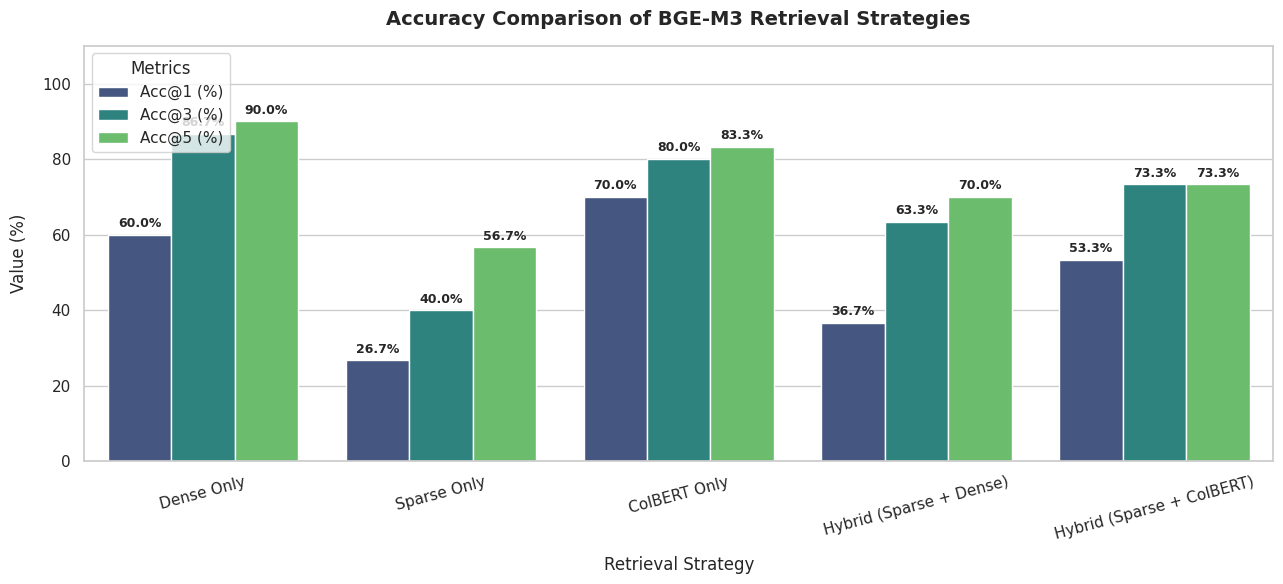

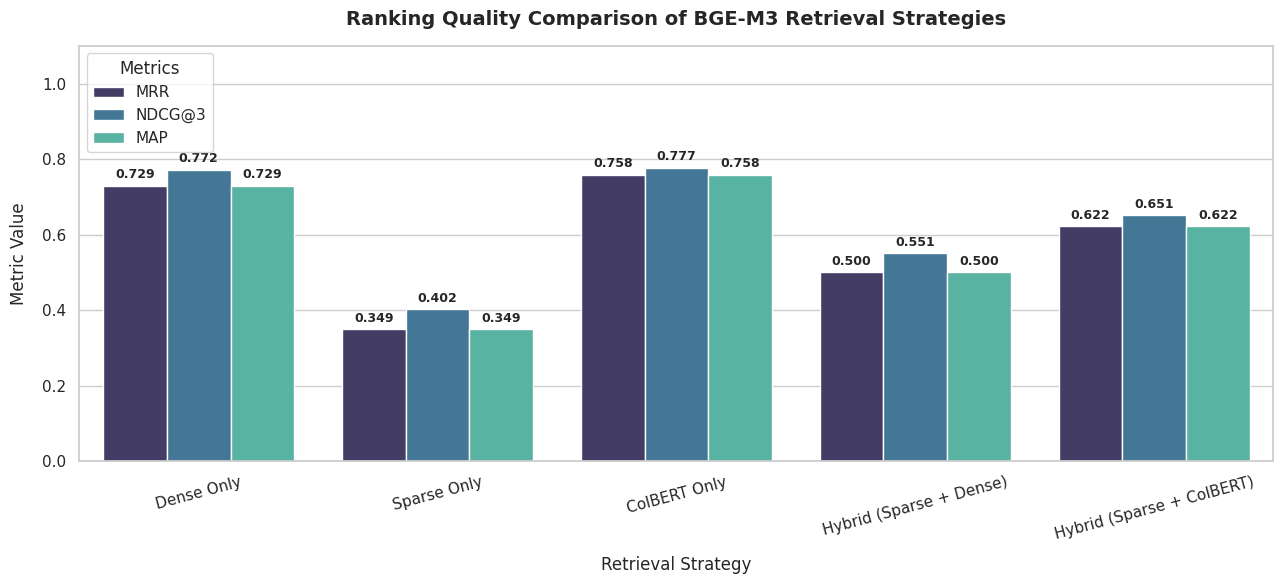

In [4]:
import os
import gc
import json
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "/content/parsed_pdf.json"
DATASET_PATH = "/content/test_dataset.json"

def load_corpus_data(json_path):
    if not os.path.exists(json_path):
        raise FileNotFoundError(f"file {json_path} is not found")

    with open(json_path, 'r', encoding='utf-8') as f:
        parsed_data = json.load(f)

    chunks = []
    for item in parsed_data:
        if isinstance(item, dict) and item.get("text"):
            chunks.append(str(item["text"]).strip())
        elif isinstance(item, str):
            chunks.append(item.strip())

    return [c for c in chunks if len(c) > 5]

def load_validation_dataset(json_path):
    if not os.path.exists(json_path):
        raise FileNotFoundError(f"test dataset {json_path} is not found")

    with open(json_path, 'r', encoding='utf-8') as f:
        return json.load(f)

def calculate_ndcg(rank):
    if rank == 1: return 1.0
    elif 2 <= rank <= 5: return 1.0 / np.log2(rank + 1)
    return 0.0

def min_max_normalize(scores):
    s_min, s_max = np.min(scores), np.max(scores)
    if s_max == s_min:
        return np.zeros_like(scores)
    return (scores - s_min) / (s_max - s_min)

def get_multi_vectors(texts, tokenizer, model, device, max_length=512):
    inputs = tokenizer(texts, padding=True, truncation=True, max_length=max_length, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        dense_embeddings = outputs.last_hidden_state[:, 0]
        dense_embeddings = F.normalize(dense_embeddings, p=2, dim=-1)

        colbert_embeddings = outputs.last_hidden_state
        colbert_embeddings = F.normalize(colbert_embeddings, p=2, dim=-1)

        input_mask = inputs['attention_mask'].unsqueeze(-1)
        masked_states = outputs.last_hidden_state * input_mask
        sparse_scores = torch.sum(torch.abs(masked_states), dim=-1)

    return dense_embeddings.cpu(), colbert_embeddings.cpu(), sparse_scores.cpu(), inputs['input_ids'].cpu()

def plot_benchmark_results(df):
    sns.set_theme(style="whitegrid")
    output_dir = "/content/bge_m3_plots"
    os.makedirs(output_dir, exist_ok=True)

    metrics_quality = ["Acc@1 (%)", "Acc@3 (%)", "Acc@5 (%)"]
    df_melted = df.melt(id_vars="Search Combination (BGE-M3)", value_vars=metrics_quality, var_name="Metric", value_name="Value")

    plt.figure(figsize=(13, 6))
    ax1 = sns.barplot(x="Search Combination (BGE-M3)", y="Value", hue="Metric", data=df_melted, palette="viridis")
    plt.title("Accuracy Comparison of BGE-M3 Retrieval Strategies", pad=15, weight='bold', fontsize=14)
    plt.xlabel("Retrieval Strategy", labelpad=10, fontsize=12)
    plt.ylabel("Value (%)", labelpad=10, fontsize=12)
    plt.ylim(0, 110)
    plt.xticks(rotation=15)
    plt.legend(title="Metrics", loc="upper left")
    for p in ax1.patches:
        if p.get_height() > 0:
            ax1.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=9, weight='semibold')
    plt.tight_layout()
    plt.savefig(f"{output_dir}/accuracy_comparison.png", dpi=300)
    plt.show()

    metrics_ranking = ["MRR", "NDCG@3", "MAP"]
    df_melted_rank = df.melt(id_vars="Search Combination (BGE-M3)", value_vars=metrics_ranking, var_name="Metric", value_name="Value")

    plt.figure(figsize=(13, 6))
    ax2 = sns.barplot(x="Search Combination (BGE-M3)", y="Value", hue="Metric", data=df_melted_rank, palette="mako")
    plt.title("Ranking Quality Comparison of BGE-M3 Retrieval Strategies", pad=15, weight='bold', fontsize=14)
    plt.xlabel("Retrieval Strategy", labelpad=10, fontsize=12)
    plt.ylabel("Metric Value", labelpad=10, fontsize=12)
    plt.ylim(0, 1.1)
    plt.xticks(rotation=15)
    plt.legend(title="Metrics", loc="upper left")
    for p in ax2.patches:
        if p.get_height() > 0:
            ax2.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=9, weight='semibold')
    plt.tight_layout()
    plt.savefig(f"{output_dir}/ranking_comparison.png", dpi=300)
    plt.show()

if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"

    corpus_texts = load_corpus_data(DATA_PATH)
    test_dataset = load_validation_dataset(DATASET_PATH)

    print(f"the number of corpus chunks: {len(corpus_texts)} | testing queries: {len(test_dataset)}")

    tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-m3")
    model = AutoModel.from_pretrained("BAAI/bge-m3").to(device)
    model.eval()

    batch_size = 16
    corpus_dense, corpus_colbert, corpus_sparse, corpus_input_ids = [], [], [], []

    for i in range(0, len(corpus_texts), batch_size):
        batch_texts = corpus_texts[i:i+batch_size]
        d, c, s, ids = get_multi_vectors(batch_texts, tokenizer, model, device)
        corpus_dense.append(d)
        corpus_colbert.append(c)
        corpus_sparse.append(s)
        corpus_input_ids.append(ids)

    corpus_dense = torch.cat(corpus_dense, dim=0)

    strategies = ["Dense Only", "Sparse Only", "ColBERT Only", "Hybrid (Sparse + Dense)", "Hybrid (Sparse + ColBERT)"]
    metrics = {
        strat: {
            "acc_1": [], "acc_3": [], "acc_5": [],
            "p_3": [], "p_5": [], "f1_3": [], "f1_5": [],
            "mrr": [], "ndcg": [], "map": []
        } for strat in strategies
    }

    for item in tqdm(test_dataset, desc="Calculating scores"):
        query = item["query"]
        target_clean = item["target"].strip()

        q_dense, q_colbert, q_sparse, q_ids = get_multi_vectors([query], tokenizer, model, device)
        q_dense, q_colbert, q_sparse, q_ids = q_dense[0], q_colbert[0], q_sparse[0], q_ids[0]

        scores_dense = torch.matmul(corpus_dense, q_dense).numpy()

        scores_sparse = np.zeros(len(corpus_texts))
        idx_counter = 0
        q_ids_set = set(q_ids.tolist())
        q_sparse_dict = {tid: q_sparse[i].item() for i, tid in enumerate(q_ids.tolist())}

        for b_sparse, b_ids in zip(corpus_sparse, corpus_input_ids):
            for d_sparse, d_ids in zip(b_sparse, b_ids):
                d_ids_list = d_ids.tolist()
                common_tokens = q_ids_set.intersection(d_ids_list)
                score = 0.0
                if common_tokens:
                    d_sparse_dict = {tid: d_sparse[i].item() for i, tid in enumerate(d_ids_list)}
                    for token in common_tokens:
                        score += q_sparse_dict[token] * d_sparse_dict[token]
                scores_sparse[idx_counter] = score
                idx_counter += 1

        scores_colbert = np.zeros(len(corpus_texts))
        idx_counter = 0
        for b_colbert in corpus_colbert:
            for d_colbert in b_colbert:
                token_similarities = torch.matmul(q_colbert, d_colbert.T)
                max_sim_per_q_token, _ = torch.max(token_similarities, dim=1)
                scores_colbert[idx_counter] = torch.sum(max_sim_per_q_token).item()
                idx_counter += 1

        norm_dense = min_max_normalize(scores_dense)
        norm_sparse = min_max_normalize(scores_sparse)
        norm_colbert = min_max_normalize(scores_colbert)

        score_sparse_dense = 0.625 * norm_sparse + 0.375 * norm_dense
        score_sparse_colbert = 0.365 * norm_sparse + 0.635 * norm_colbert

        strat_maps = {
            "Dense Only": scores_dense,
            "Sparse Only": scores_sparse,
            "ColBERT Only": scores_colbert,
            "Hybrid (Sparse + Dense)": score_sparse_dense,
            "Hybrid (Sparse + ColBERT)": score_sparse_colbert
        }

        for strat in strategies:
            sc = strat_maps[strat]
            top_5_idx = np.argsort(-sc)[:5]
            found_texts = [corpus_texts[idx] for idx in top_5_idx]

            rank = -1
            for idx, text in enumerate(found_texts):
                if text == target_clean or target_clean in text or text in target_clean:
                    rank = idx + 1
                    break

            metrics[strat]["acc_1"].append(1.0 if rank == 1 else 0.0)

            if 1 <= rank <= 5:
                metrics[strat]["mrr"].append(1.0 / rank)
                metrics[strat]["ndcg"].append(calculate_ndcg(rank))
                metrics[strat]["map"].append(1.0 / rank)
            else:
                metrics[strat]["mrr"].append(0.0)
                metrics[strat]["ndcg"].append(0.0)
                metrics[strat]["map"].append(0.0)

            for k in [3, 5]:
                slice_chunks = found_texts[:k]
                is_found = any(text == target_clean or target_clean in text or text in target_clean for text in slice_chunks)

                acc_val = 1.0 if is_found else 0.0
                rec_val = 1.0 if is_found else 0.0
                prec_val = (1.0 / k) if is_found else 0.0
                f1_val = (2 * prec_val * rec_val) / (prec_val + rec_val) if is_found else 0.0

                metrics[strat][f"acc_{k}"].append(acc_val)
                metrics[strat][f"p_{k}"].append(prec_val)
                metrics[strat][f"f1_{k}"].append(f1_val)

    final_rows = []
    for strat in strategies:
        final_rows.append({
            "Search Combination (BGE-M3)": strat,
            "Acc@1 (%)": round(np.mean(metrics[strat]["acc_1"]) * 100, 2),
            "Acc@3 (%)": round(np.mean(metrics[strat]["acc_3"]) * 100, 2),
            "Acc@5 (%)": round(np.mean(metrics[strat]["acc_5"]) * 100, 2),
            "P@3 (%)": round(np.mean(metrics[strat]["p_3"]) * 100, 2),
            "P@5 (%)": round(np.mean(metrics[strat]["p_5"]) * 100, 2),
            "F1@3 (%)": round(np.mean(metrics[strat]["f1_3"]) * 100, 2),
            "F1@5 (%)": round(np.mean(metrics[strat]["f1_5"]) * 100, 2),
            "MRR": round(np.mean(metrics[strat]["mrr"]), 3),
            "NDCG@3": round(np.mean(metrics[strat]["ndcg"]), 3),
            "MAP": round(np.mean(metrics[strat]["map"]), 3)
        })

    df_res = pd.DataFrame(final_rows)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    print(df_res.to_string(index=False))

    plot_benchmark_results(df_res)

    del model
    if device == "cuda":
        torch.cuda.empty_cache()
    gc.collect()